# Understanding the Bellman Equation in Q-Learning

This notebook breaks down the core of Q-Learning: the **Bellman Equation**. We'll go step-by-step to see how an agent's "brain"—the Q-table—is updated. We'll use a simple example inspired by the `FrozenLake` environment.

## What is the Bellman Equation?

The Bellman Equation is the update rule used in Q-learning. It tells us how to improve our estimate for the value of a state-action pair based on new information we gather from the environment.

Here is the formula:

$$Q(s, a) \leftarrow Q(s, a) + \alpha \left[ r + \gamma \max_{a'} Q(s', a') - Q(s, a) \right]$$

It looks complex, but let's break it down into plain English:

**`New Q-value = Old Q-value + Learning Rate * (Temporal Difference Error)`**

Where:
*   **`Q(s, a)`**: The current Q-value for being in **state `s`** and taking **action `a`**. This is our old estimate.
*   **`α` (alpha)**: The **Learning Rate** (e.g., 0.1). This controls how much we update our Q-value. A small `α` means we learn slowly, while a large `α` means we learn fast.
*   **`r`**: The immediate **Reward** we get after taking action `a` from state `s`.
*   **`γ` (gamma)**: The **Discount Factor** (e.g., 0.95). This determines how much we value future rewards. A `γ` close to 1 means we care a lot about future rewards, while a `γ` close to 0 means we only care about the immediate reward.
*   **`max Q(s', a')`**: The **best possible Q-value** we can get from our **next state `s'`**. This is the agent looking one step ahead and picking the most valuable action from its new position.
*   **`r + γ * max Q(s', a')`**: This is the **learned value** or the "new, better estimate" of the Q-value. It's the immediate reward plus the discounted estimate of the future reward.
*   **`[...] - Q(s, a)`**: This whole part is the **Temporal Difference (TD) Error**. It's the difference between our new estimate and our old one. It represents the "surprise" or how wrong our initial estimate was.

## A Step-by-Step Example

Let's simulate a tiny piece of the `FrozenLake` world. Imagine this simple 3-state environment:

`Start (S0)` <-> `Frozen (S1)` <-> `Goal (S2)`


/media/NOCTURNOEXTRA/Alejandro/wip-clase/.venv/lib/python3.13/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


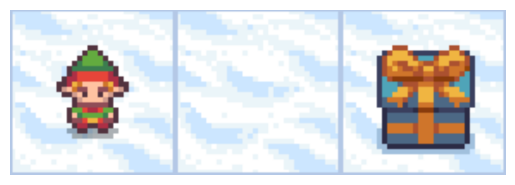

In [ ]:
import gymnasium as gym
import matplotlib.pyplot as plt

env = gym.make('FrozenLake-v1', desc=["SFG"], is_slippery=False, render_mode="rgb_array")
env.reset()

def show_env(env):
    '''Render and display the environment in the notebook.'''
    img = env.render()
    plt.imshow(img)
    plt.axis('off')
    plt.show()

show_env(env)


*   **States**: S0, S1, S2
*   **Actions**: 0 (Left), 1 (Right)
*   **Rewards**:
    *   +1 for reaching the Goal (S2)
    *   0 for any other move.

Let's set our hyperparameters:
*   Learning Rate (`α`) = 0.1
*   Discount Factor (`γ`) = 0.9

### Initial Q-Table

Our agent starts with no knowledge. The Q-table is a `[states x actions]` matrix filled with zeros.

$$
\begin{array}{c c}
    & \color{gray} \begin{matrix}
    \text{Left (0)} & \text{Right (1)} \end{matrix}
    \\
    \color{gray}
    \begin{matrix} \text{S0} \\ \text{S1} \\ \text{S2} \end{matrix}
    &
    \begin{bmatrix}
        0 & \quad 0 \\
        0 & \quad 0 \\
        0 & \quad 0
    \end{bmatrix}
\end{array}
$$

In [ ]:
import numpy as np

q_table = np.zeros((3, 2)) # 3 states, 2 actions

print("Initial Q-Table:")
print(q_table)

Initial Q-Table:
[[0. 0.]
 [0. 0.]
 [0. 0.]]


### Step 1: Agent moves from S0 to S1

1.  **Current State (`s`)**: S0
2.  **Action (`a`)**: 1 (Move Right)
3.  **Observation**:
    *   New State (`s'`) = S1
    *   Reward (`r`) = 0

Now, let's plug this into the Bellman equation to update `Q(S0, Right)`.

**Formula**: `Q(s, a) = Q(s, a) + α * [r + γ * max Q(s', a') - Q(s, a)]`

**Calculation**:
*   `Q(S0, Right)` = `q_table[0, 1]` = **0**
*   `α` = **0.1**
*   `r` = **0**
*   `γ` = **0.9**
*   `max Q(S1, a')`: The best Q-value from state S1. We look at the row for S1 in our Q-table (`q_table[1]`). The values are `[0, 0]`. The max value is **0**.

Let's substitute:
`New Q(S0, Right) = 0 + 0.1 * [0 + 0.9 * 0 - 0]`
`New Q(S0, Right) = 0`

Not very exciting. The Q-value didn't change because no reward was found. This is common at the beginning of training.

### Step 2: Agent moves from S1 to S2 (The Goal!)

1.  **Current State (`s`)**: S1
2.  **Action (`a`)**: 1 (Move Right)
3.  **Observation**:
    *   New State (`s'`) = S2 (Goal)
    *   Reward (`r`) = **+1**

Let's update `Q(S1, Right)`.

**Calculation**:
*   `Q(S1, Right)` = `q_table[1, 1]` = **0**
*   `α` = **0.1**
*   `r` = **1**
*   `γ` = **0.9**
*   `max Q(S2, a')`: The best Q-value from state S2. The S2 row in our Q-table (`q_table[2]`) is `[0, 0]`. The max value is **0**. (S2 is a terminal state, so future rewards from here are 0).

Let's substitute:
`New Q(S1, Right) = 0 + 0.1 * [1 + 0.9 * 0 - 0]`
`New Q(S1, Right) = 0.1 * [1]`
`New Q(S1, Right) = 0.1`

**This is our first update!** The agent learned that moving right from S1 is slightly good.

In [ ]:
q_table[1, 1] = 0.1
print("Q-Table after Step 2:")
print(q_table)

Q-Table after Step 2:
[[0.  0. ]
 [0.  0.1]
 [0.  0. ]]


### Step 3: A New Episode - Agent moves from S0 to S1 again

Now the magic happens. The reward information starts to flow backward.

1.  **Current State (`s`)**: S0
2.  **Action (`a`)**: 1 (Move Right)
3.  **Observation**:
    *   New State (`s'`) = S1
    *   Reward (`r`) = 0

Let's update `Q(S0, Right)` again.

**Calculation**:
*   `Q(S0, Right)` = `q_table[0, 1]` = **0** (from before)
*   `α` = **0.1**
*   `r` = **0**
*   `γ` = **0.9**
*   `max Q(S1, a')`: **This is the key difference!** We look at the row for S1 in our updated Q-table (`q_table[1]`). The values are `[0, 0.1]`. The max value is now **0.1**.

Let's substitute:
`New Q(S0, Right) = 0 + 0.1 * [0 + 0.9 * 0.1 - 0]`
`New Q(S0, Right) = 0.1 * [0.09]`
`New Q(S0, Right) = 0.009`

The value of being at `S0` and moving right has now increased! The agent is learning that this action leads to a state (S1) which has a known, positive future value. The reward from reaching the goal is slowly propagating backward to the states that lead to it.

In [ ]:
q_table[0, 1] = 0.009
print("Q-Table after Step 3:")
print(q_table)

Q-Table after Step 3:
[[0.    0.009]
 [0.    0.1  ]
 [0.    0.   ]]


## How it Looks in Code

Here is the Python code from the `frozen_lake.ipynb` notebook that implements this exact formula. You can see how each variable maps directly to the equation.

In [ ]:
# From the training loop:
# Qtable[state][action] = Qtable[state][action] + learning_rate * (
#     reward + gamma * np.max(Qtable[new_state]) - Qtable[state][action]
# )

# Let's map it to our last calculation:
s = 0
a = 1
s_prime = 1
r = 0

learning_rate = 0.1
gamma = 0.9

# q_table before update
q_table_before = np.array([[0., 0.], [0., 0.1], [0., 0.]])

# The Bellman update in code
old_q_value = q_table_before[s, a]                 # Q(s, a)
max_future_q = np.max(q_table_before[s_prime])   # max Q(s', a')
td_error = r + gamma * max_future_q - old_q_value

new_q_value = old_q_value + learning_rate * td_error

print(f"Old Q-value: {old_q_value}")
print(f"Max future Q-value from S{s_prime}: {max_future_q}")
print(f"TD Error: {td_error:.3f}")
print(f"New Q-value for Q(S{s}, Right): {new_q_value:.3f}")

Old Q-value: 0.0
Max future Q-value from S1: 0.1
TD Error: 0.090
New Q-value for Q(S0, Right): 0.009


## Conclusion

By repeatedly applying the Bellman Equation over thousands of episodes, the agent explores the environment and slowly builds a Q-table that accurately predicts the long-term reward of every action from every state. The initial small reward values gradually spread and flow backward from the goal state, carving out an optimal path. 

The final Q-table in `frozen_lake.ipynb` is simply the result of this process happening thousands of times, creating a complete "cheat sheet" for navigating the icy terrain.